# Adaptive Email Spam Detection System
### River Online-Learning Pipeline — TF-IDF + Multinomial Naive Bayes + ADWIN
---
**Dataset:** LEVI_DATASET.csv (same source as the Static SVM notebook)
**Labels:** `0` = Legitimate (Ham) Email &nbsp;|&nbsp; `1` = Spam Email
**Pipeline:** Raw Data → Cleanup → Pre-processing → Train/Test Split → Online Pipeline (River TF-IDF + MultinomialNB) → Incremental Warm-Up Training (`learn_one`) → Evaluation → Custom Prediction → Live Feedback Demonstration

**How this differs from the Static SVM notebook:**
This model is trained **incrementally** — one email at a time via River's `learn_one`
method — rather than in a single batch `fit()` call. It also builds its **own** online
TF-IDF vocabulary rather than reusing the Static SVM's fixed vectorizer, so its
vocabulary can keep growing after this notebook finishes running, every time the
live application receives a confirmed user correction.

This notebook is a standalone, runnable companion to the production code at:
- `scripts/initialize_adaptive_model.py` — the warm-up procedure reproduced below
- `backend/app/ml/adaptive_model.py` — how the live application serves predictions
  and applies feedback updates using this same kind of pipeline
- `backend/app/ml/preprocessing.py` — the shared text-cleaning functions reproduced
  below (`clean_text`, `tokenize_stem_lemmatize`)


In [1]:
# ============================================================
# SETUP — Import Libraries
# - pandas / numpy: data handling
# - re: regular-expression based text cleaning
# - nltk: stop-word removal, tokenisation, stemming, lemmatisation
#   (identical tools to the Static SVM notebook, for a fair comparison)
# - river: the online-learning library used for the adaptive pipeline
# - sklearn: only used here for train_test_split, so both models are
#   evaluated on the SAME held-out test rows
# - matplotlib: result charts
# ============================================================

import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from river import compose, feature_extraction, naive_bayes
from river.drift import ADWIN
from sklearn.model_selection import train_test_split

for pkg in ["stopwords", "punkt", "punkt_tab", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

print("Libraries loaded.")


Libraries loaded.


In [2]:
# ============================================================
# STAGE 1 — Step 1: Load the Dataset
# - Identical loading procedure to the Static SVM notebook:
#   combine 'subject' and 'body' into one 'email_text' column,
#   keep only 'email_text' and 'label'.
# - Using the SAME source file and SAME combination rule means both
#   models start from an identical raw dataset.
# ============================================================

DATA_PATH = "../data/raw/LEVI_DATASET.csv"

raw_df = pd.read_csv(DATA_PATH)
raw_df["email_text"] = raw_df["subject"].fillna("") + " " + raw_df["body"].fillna("")
df = raw_df[["email_text", "label"]].copy()

print(f"Loaded {len(df)} raw rows.")
df.head()


Loaded 39154 raw rows.


,email_text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [3]:
# ============================================================
# STAGE 1 — Step 2: Remove Duplicates and Missing Values
# - Same cleaning rule as the Static SVM notebook, applied in the same
#   order, so the row set going into preprocessing matches exactly.
# ============================================================

count_before = len(df)
df = df.drop_duplicates(subset=["email_text"]).reset_index(drop=True)
df = df.dropna(subset=["email_text", "label"]).reset_index(drop=True)
count_after = len(df)

print(f"Records before cleaning : {count_before}")
print(f"Records after cleaning  : {count_after}")
df["label"].value_counts()


Records before cleaning : 39154
Records after cleaning  : 39154


label
1    21842
0    17312
Name: count, dtype: int64

## STAGE 2 — Text Cleaning

The functions below are reproduced directly from
`backend/app/ml/preprocessing.py`, the module shared by **both** the
live prediction API and this notebook's training procedure. Using the
identical function for training and for live serving is essential for
an online model — whatever cleaning a new email goes through in
production must match what this warm-up data went through, or the
model's warm-started vocabulary would not correspond to what it later
receives from real users.


In [4]:
# ============================================================
# STAGE 2 — Step 1: Define the Cleaning Function (clean_text)
# Applied in this exact order:
#   1. Strip HTML tags
#   2. Strip URLs
#   3. Strip email addresses
#   4. Strip punctuation
#   5. Strip numbers
#   6. Strip any remaining non-alphabetic characters
#   7. Collapse extra whitespace
#   8. Lowercase
#   9. Remove English stop words
# ============================================================

_HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
_URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
_EMAIL_ADDRESS_PATTERN = re.compile(r"\b[\w.+-]+@[\w.-]+\.\w+\b")
_PUNCTUATION_PATTERN = re.compile(r"[^\w\s]")
_NUMBER_PATTERN = re.compile(r"\d+")
_NON_ALPHA_PATTERN = re.compile(r"[^a-zA-Z\s]")
_WHITESPACE_PATTERN = re.compile(r"\s+")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = _HTML_TAG_PATTERN.sub(" ", str(text))
    text = _URL_PATTERN.sub(" ", text)
    text = _EMAIL_ADDRESS_PATTERN.sub(" ", text)
    text = _PUNCTUATION_PATTERN.sub(" ", text)
    text = _NUMBER_PATTERN.sub(" ", text)
    text = _NON_ALPHA_PATTERN.sub(" ", text)
    text = _WHITESPACE_PATTERN.sub(" ", text).strip()
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

print("clean_text() defined.")


clean_text() defined.


In [5]:
# ============================================================
# STAGE 2 — Step 2: Define Tokenisation, Stemming and Lemmatisation
# (tokenize_stem_lemmatize)
# - Tokenise into individual words
# - Reduce each word to its root form (Porter Stemmer)
# - Reduce each word to its dictionary base form (WordNet Lemmatizer)
# - Rejoin into the final 'processed_text' string
#
# NOTE — what is intentionally NOT here:
# The Static SVM notebook additionally removes the 20 most frequent
# words and all words occurring fewer than 2 times, computed across the
# WHOLE training corpus, before this step. That pruning is a corpus-wide
# statistic — it cannot be recomputed for a single incoming email at
# prediction time. Because this adaptive model must process one email
# at a time, both now (during warm-up) and later (during live use), it
# uses the SAME pipeline in both cases and therefore skips that
# training-only pruning step entirely.
# ============================================================

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def tokenize_stem_lemmatize(text):
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

def preprocess_for_inference(email_text):
    return tokenize_stem_lemmatize(clean_text(email_text))

print("tokenize_stem_lemmatize() and preprocess_for_inference() defined.")


tokenize_stem_lemmatize() and preprocess_for_inference() defined.


In [6]:
# ============================================================
# STAGE 2 — Step 3: Apply Preprocessing to the Full Dataset
# - This step is the slow part (tokenising/stemming/lemmatising every
#   row) — expect this cell to take a minute or two on the full dataset.
# ============================================================

t0 = time.time()
df["processed_text"] = df["email_text"].apply(preprocess_for_inference)
print(f"Preprocessing complete in {time.time() - t0:.1f}s.")
df[["email_text", "processed_text", "label"]].head()


Preprocessing complete in 72.5s.


,email_text,processed_text,label
0,"Never agree to be a loser Buck up, your troubl...",never agre loser buck troubl caus small dimens...,1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,befriend jenna jameson upgrad sex pleasur tech...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,cnn com daili top daili top cnn com top video ...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,svn commit r spamassassin trunk lib mail spama...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,specialpricespharmmoreinfo welcomefastshipping...,1


In [7]:
# ============================================================
# STAGE 3 — Step 1: Train/Test Split
# - IDENTICAL parameters to the Static SVM notebook:
#   test_size=0.20, random_state=42, stratify=y
# - Using the same split means the 7,831-row test set below is the
#   SAME set of emails the Static SVM was evaluated on — neither model
#   has ever seen these rows during training.
# ============================================================

y = df["label"].to_numpy()

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.20, random_state=42, stratify=y
)

train_texts = df["processed_text"].iloc[train_idx].to_numpy()
train_labels = y[train_idx]
test_texts = df["processed_text"].iloc[test_idx].to_numpy()
test_labels = y[test_idx]

split_summary = pd.DataFrame({
    "Split": ["Training Set", "Testing Set", "Total"],
    "Number of Entries": [len(train_texts), len(test_texts), len(df)],
    "Percentage (%)": [80.00, 20.00, 100.00],
})
split_summary


,Split,Number of Entries,Percentage (%)
0,Training Set,31323,80.0
1,Testing Set,7831,20.0
2,Total,39154,100.0


## STAGE 4 — Building the Online Learning Pipeline

Unlike the Static SVM's `TfidfVectorizer` (fit once, on the whole
training corpus, then frozen), River's `TFIDF` transformer recomputes
its word-importance statistics with every new document it processes —
during this warm-up **and** during every future live prediction and
feedback update. It is chained directly to the `MultinomialNB`
classifier using River's `compose.Pipeline`, so a single call handles
both feature extraction and classification together.


In [8]:
# ============================================================
# STAGE 4 — Step 1: Build the River Pipeline
# - feature_extraction.TFIDF(): online TF-IDF vectorisation
# - naive_bayes.MultinomialNB(): probabilistic text classifier
# ============================================================

model = compose.Pipeline(
    ("tfidf", feature_extraction.TFIDF()),
    ("nb", naive_bayes.MultinomialNB()),
)

print("River pipeline constructed:")
print(model)


River pipeline constructed:
TFIDF | MultinomialNB


## STAGE 5 — Incremental Warm-Up Training

This is the online-learning equivalent of the Static SVM's `.fit()`
call — but instead of one call over the whole matrix, the model is
shown **one email at a time**, 31,323 individual `learn_one` calls per
pass, repeated across 8 shuffled passes (250,584 total calls). Warm-up
exists because a freshly-initialised online model has no knowledge at
all; this stage gives it a reasonable starting point using historical
data, before it goes on to learn from live user feedback after
deployment.


In [9]:
# ============================================================
# STAGE 5 — Step 1: Incremental Training via learn_one
# - 8 shuffled epochs over the training set (matches the production
#   warm-up in scripts/initialize_adaptive_model.py exactly)
# - Shuffling changes the presentation order each epoch; multiple
#   epochs let the model encounter every example more than once.
# ============================================================

LABEL_NAME = {0: "ham", 1: "spam"}
WARM_UP_EPOCHS = 8
rng = np.random.default_rng(42)

t0 = time.time()
for epoch in range(WARM_UP_EPOCHS):
    order = rng.permutation(len(train_texts))
    for i in order:
        model.learn_one(train_texts[i], LABEL_NAME[train_labels[i]])
    print(f"Epoch {epoch + 1}/{WARM_UP_EPOCHS} complete ({time.time() - t0:.1f}s elapsed)")

print(f"\nWarm-up training complete in {time.time() - t0:.1f}s "
      f"({len(train_texts) * WARM_UP_EPOCHS} total learn_one calls).")


Epoch 1/8 complete (7.7s elapsed)


Epoch 2/8 complete (15.5s elapsed)


Epoch 3/8 complete (23.2s elapsed)


Epoch 4/8 complete (30.6s elapsed)


Epoch 5/8 complete (38.4s elapsed)


Epoch 6/8 complete (46.2s elapsed)


Epoch 7/8 complete (53.9s elapsed)


Epoch 8/8 complete (61.7s elapsed)

Warm-up training complete in 61.7s (250584 total learn_one calls).


## STAGE 6 — Evaluation on the Held-Out Test Set

In [10]:
# ============================================================
# STAGE 6 — Step 1: Predict on the Test Set
# - predict_one() is called once per test email (River has no batch
#   prediction path — this mirrors exactly how the live API predicts
#   a single incoming email).
# ============================================================

y_pred = []
for text in test_texts:
    pred_name = model.predict_one(text) or "ham"
    y_pred.append(1 if pred_name == "spam" else 0)
y_pred = np.array(y_pred)

results_df = pd.DataFrame({
    "Actual Label": test_labels,
    "Predicted Label": y_pred,
    "Actual Class": ["Spam Email" if l == 1 else "Ham Email" for l in test_labels],
    "Predicted Class": ["Spam Email" if l == 1 else "Ham Email" for l in y_pred],
})
print(f"Predictions generated for {len(y_pred)} test emails.")
results_df.head(10)


Predictions generated for 7831 test emails.


,Actual Label,Predicted Label,Actual Class,Predicted Class
0,1,1,Spam Email,Spam Email
1,0,0,Ham Email,Ham Email
2,0,0,Ham Email,Ham Email
3,1,1,Spam Email,Spam Email
4,1,1,Spam Email,Spam Email
5,1,1,Spam Email,Spam Email
6,1,1,Spam Email,Spam Email
7,1,1,Spam Email,Spam Email
8,0,0,Ham Email,Ham Email
9,0,0,Ham Email,Ham Email


In [11]:
# ============================================================
# STAGE 6 — Step 2: Evaluation Metrics (Table 4.3)
# - Accuracy, Precision, Recall, F1-score — same metrics, same
#   definitions, as the Static SVM notebook, for direct comparability.
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(test_labels, y_pred)
precision = precision_score(test_labels, y_pred)
recall = recall_score(test_labels, y_pred)
f1 = f1_score(test_labels, y_pred)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)],
    "Score (%)": [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%"],
})
metrics_table


,Metric,Score,Score (%)
0,Accuracy,0.9871,98.71%
1,Precision,0.9984,99.84%
2,Recall,0.9785,97.85%
3,F1-Score,0.9883,98.83%


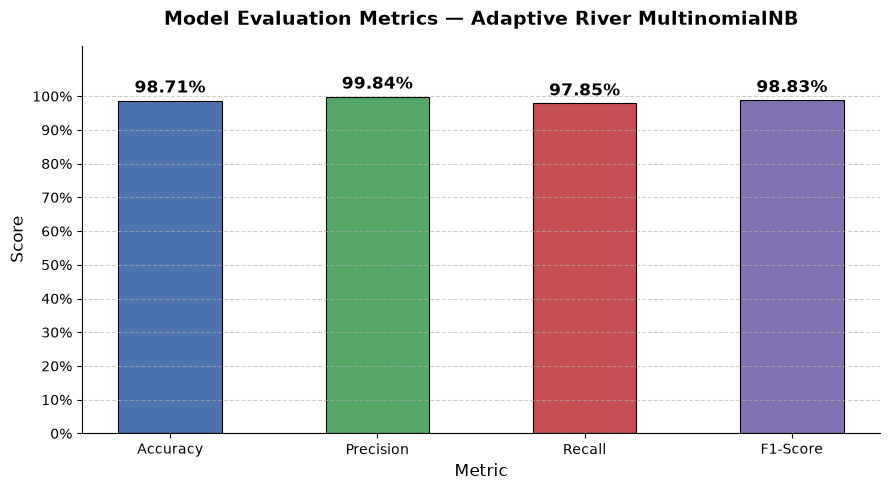

In [12]:
# ============================================================
# STAGE 6 — Step 3: Evaluation Metrics Bar Chart
# ============================================================

metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_values = [accuracy, precision, recall, f1]
bar_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics_names, metrics_values, color=bar_colors, width=0.5, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f"{val*100:.2f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Model Evaluation Metrics — Adaptive River MultinomialNB", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("adaptive_model_metrics_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
# ============================================================
# STAGE 6 — Step 4: Confusion Matrix Summary Table
# - TN: Legitimate emails correctly identified
# - FP: Legitimate emails incorrectly flagged as spam
# - FN: Spam emails missed
# - TP: Spam emails correctly detected
# ============================================================

cm = confusion_matrix(test_labels, y_pred)
TN, FP, FN, TP = cm.ravel()
total = TN + FP + FN + TP

cm_summary = pd.DataFrame({
    "Term": ["True Negative (TN)", "False Positive (FP)", "False Negative (FN)", "True Positive (TP)", "Total Test Emails"],
    "Meaning": [
        "Legitimate emails correctly predicted as legitimate",
        "Legitimate emails incorrectly predicted as spam",
        "Spam emails incorrectly predicted as legitimate",
        "Spam emails correctly predicted as spam",
        "All emails evaluated in the test set",
    ],
    "Count": [TN, FP, FN, TP, total],
    "Percentage (%)": [f"{TN/total*100:.2f}%", f"{FP/total*100:.2f}%", f"{FN/total*100:.2f}%", f"{TP/total*100:.2f}%", "100.00%"],
})
cm_summary


,Term,Meaning,Count,Percentage (%)
0,True Negative (TN),Legitimate emails correctly predicted as legit...,3455,44.12%
1,False Positive (FP),Legitimate emails incorrectly predicted as spam,7,0.09%
2,False Negative (FN),Spam emails incorrectly predicted as legitimate,94,1.20%
3,True Positive (TP),Spam emails correctly predicted as spam,4275,54.59%
4,Total Test Emails,All emails evaluated in the test set,7831,100.00%


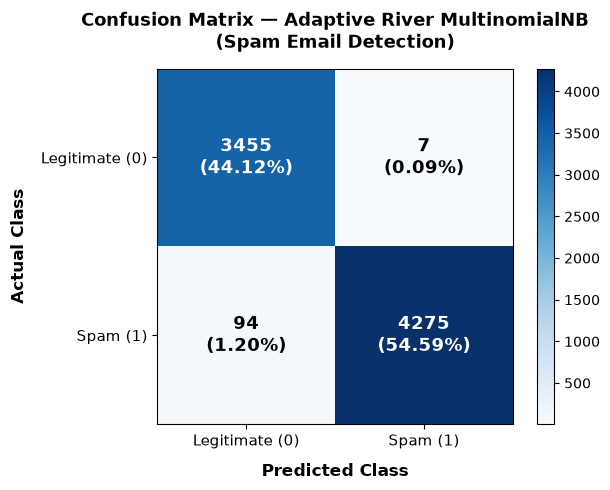

In [14]:
# ============================================================
# STAGE 6 — Step 5: Confusion Matrix Heatmap
# ============================================================

labels_display = ["Legitimate (0)", "Spam (1)"]
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = count / total * 100
        color = "white" if count > thresh else "black"
        ax.text(j, i, f"{count}\n({percent:.2f}%)", ha="center", va="center",
                fontsize=13, fontweight="bold", color=color)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels_display, fontsize=11)
ax.set_yticklabels(labels_display, fontsize=11)
ax.set_xlabel("Predicted Class", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Actual Class", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Confusion Matrix — Adaptive River MultinomialNB\n(Spam Email Detection)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("adaptive_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## STAGE 7 — Predicting a Custom Email

Mirrors the Static SVM notebook's own custom-email cell: the identical
`preprocess_for_inference` pipeline is applied, then the trained model
predicts a class. Because this is a River model, it also reports a
genuine probability for each class (`predict_proba_one`) — something
the Static SVM's `LinearSVC` cannot do (it has no `predict_proba`).


In [15]:
# ============================================================
# STAGE 7 — Step 1: Predict Using Custom Email Text
# ============================================================

custom_email = """
Congratulations! You have been selected as the lucky winner of our exclusive
lottery draw. You have won $1,000,000. To claim your prize, click the link
below and provide your bank account number and personal details immediately.
This offer expires in 24 hours. Act now!
"""

processed_custom_email = preprocess_for_inference(custom_email)
prediction = model.predict_one(processed_custom_email)
probabilities = model.predict_proba_one(processed_custom_email)

print("=" * 50)
print("       EMAIL CLASSIFICATION RESULT")
print("=" * 50)
print(f"\n  Predicted Class : {'Spam Email' if prediction == 'spam' else 'Legitimate Email'}")
print(f"  P(spam)         : {probabilities.get('spam', 0):.4f}")
print(f"  P(legitimate)   : {probabilities.get('ham', 0):.4f}")
print("\n" + "=" * 50)


       EMAIL CLASSIFICATION RESULT

  Predicted Class : Spam Email
  P(spam)         : 0.5740
  P(legitimate)   : 0.4260



## STAGE 8 — Demonstrating Incremental Feedback Learning

This stage has no equivalent in the Static SVM notebook — it is the
capability that makes this model "adaptive". A single confirmed
correction is applied via `learn_one`, live, in this notebook, and the
prediction is checked again on the exact same email — reproducing what
happens inside `AdaptiveModelService.update_one` in the live
application every time a user clicks "Mark as Spam" / "Mark as
Legitimate".


In [16]:
# ============================================================
# STAGE 8 — Step 1: Apply a Simulated User Correction
# - Suppose the email above was, in fact, legitimate (a false positive).
# - The application does not simply take one uncorrected learn_one call
#   on faith: it repeats the correction, checking predict_proba_one
#   after each call, until the model's own confidence has genuinely
#   crossed a safety margin toward the corrected label (0.6) — this is
#   the confidence-margin loop implemented in
#   AdaptiveModelService.update_one, reproduced here for demonstration.
# ============================================================

CONFIDENCE_MARGIN = 0.6
MAX_LEARN_CALLS = 5000
true_label = "ham"

print(f"BEFORE correction : predicted={prediction}, "
      f"P(legitimate)={probabilities.get('ham', 0):.4f}")

learn_calls = 0
confidence = model.predict_proba_one(processed_custom_email).get(true_label, 0.0)
while confidence < CONFIDENCE_MARGIN and learn_calls < MAX_LEARN_CALLS:
    model.learn_one(processed_custom_email, true_label)
    learn_calls += 1
    confidence = model.predict_proba_one(processed_custom_email).get(true_label, 0.0)

new_prediction = model.predict_one(processed_custom_email)
print(f"AFTER correction  : predicted={new_prediction}, "
      f"P(legitimate)={confidence:.4f}  ({learn_calls} learn_one call(s) applied)")


BEFORE correction : predicted=spam, P(legitimate)=0.4260
AFTER correction  : predicted=ham, P(legitimate)=0.6033  (38 learn_one call(s) applied)


## Stage-to-Code Cross-Reference

| Notebook stage | Production code location |
|---|---|
| Stage 1 — Load & clean dataset | `scripts/initialize_adaptive_model.py` (dataset loading block) |
| Stage 2 — Text cleaning | `backend/app/ml/preprocessing.py` — `clean_text`, `tokenize_stem_lemmatize` |
| Stage 3 — Train/test split | `scripts/initialize_adaptive_model.py` — `train_test_split(...)` |
| Stage 4 — Pipeline construction | `scripts/initialize_adaptive_model.py` — `compose.Pipeline(...)` |
| Stage 5 — Warm-up training | `scripts/initialize_adaptive_model.py` — the 8-epoch `learn_one` loop |
| Stage 6 — Evaluation | `scripts/initialize_adaptive_model.py` — evaluation block, results saved to `artifacts/metadata/adaptive_model_metadata.json` |
| Stage 7 — Single prediction | `backend/app/ml/adaptive_model.py` — `AdaptiveModelService.predict()` |
| Stage 8 — Feedback learning | `backend/app/ml/adaptive_model.py` — `AdaptiveModelService.update_one()` |

This notebook runs independently of the live application (it does not
import from `backend/`) so it can be executed and re-run on its own for
documentation purposes without needing the FastAPI server running.
